In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [29]:
df = pd.read_csv("../../data/train_data.csv")

In [5]:
df.columns

Index(['SalePrice', 'YearBuilt', 'Size(sqf)', 'Floor', 'HallwayType',
       'HeatingType', 'AptManageType', 'N_Parkinglot(Ground)',
       'N_Parkinglot(Basement)', 'TimeToBusStop', 'TimeToSubway', 'N_manager',
       'N_elevators', 'SubwayStation', 'N_FacilitiesInApt',
       'N_FacilitiesNearBy(Total)', 'N_SchoolNearBy(Total)'],
      dtype='str')

In [6]:
df.describe()

,SalePrice,YearBuilt,Size(sqf),Floor,N_Parkinglot(Ground),N_Parkinglot(Basement),N_manager,N_elevators,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total)
count,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000
mean,222177.477207,2002.977934,959.958778,11.994665,192.789040,572.857662,6.313773,11.055771,5.824200,9.860330,10.872696
std,106325.535526,8.765838,384.548456,7.581330,215.455916,408.179957,3.224556,7.717030,2.344331,3.444848,4.427445
min,34070.000000,1978.000000,135.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,144752.000000,1993.000000,644.000000,6.000000,11.000000,184.000000,5.000000,5.000000,4.000000,8.000000,7.000000
50%,209588.000000,2006.000000,910.000000,11.000000,100.000000,536.000000,6.000000,11.000000,5.000000,9.000000,10.000000
75%,291570.000000,2007.000000,1160.000000,17.000000,249.000000,798.000000,8.000000,16.000000,7.000000,13.000000,15.000000
max,585840.000000,2015.000000,2337.000000,43.000000,713.000000,1321.000000,14.000000,27.000000,10.000000,16.000000,17.000000


In [8]:
df.isna().sum()

SalePrice                    0
YearBuilt                    0
Size(sqf)                    0
Floor                        0
HallwayType                  0
HeatingType                  0
AptManageType                0
N_Parkinglot(Ground)         0
N_Parkinglot(Basement)       0
TimeToBusStop                0
TimeToSubway                 0
N_manager                    0
N_elevators                  0
SubwayStation                0
N_FacilitiesInApt            0
N_FacilitiesNearBy(Total)    0
N_SchoolNearBy(Total)        0
dtype: int64

In [7]:
df.head()

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total)
0,141592,2006,814,3,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5,6.0,9.0
1,51327,1985,587,8,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
2,48672,1985,587,6,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
3,380530,2006,2056,8,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5,3.0,7.0
4,78318,1992,644,2,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0


In [33]:
df["AptManageType"].value_counts()

AptManageType
management_in_trust    3869
self_management         255
Name: count, dtype: int64

In [30]:
discrete_cols = []
binary_cols = []
to_scale_cols = []

for col in df.columns:
    vc = df[col].value_counts()
    if len(vc.keys()) > 10:
        to_scale_cols.append(col)
    elif len(vc.keys()) == 2:
        binary_cols.append((col, list(vc.keys())))
    else:
        discrete_cols.append((col, list(vc.keys())))

print(f"{to_scale_cols=}")
print(f"{discrete_cols=}")
print(f"{binary_cols=}")

to_scale_cols=['SalePrice', 'YearBuilt', 'Size(sqf)', 'Floor', 'N_Parkinglot(Ground)', 'N_Parkinglot(Basement)', 'N_elevators', 'N_FacilitiesNearBy(Total)', 'N_SchoolNearBy(Total)']
discrete_cols=[('HallwayType', ['terraced', 'mixed', 'corridor']), ('TimeToBusStop', ['0~5min', '5min~10min', '10min~15min']), ('TimeToSubway', ['0-5min', '5min~10min', '15min~20min', '10min~15min', 'no_bus_stop_nearby']), ('N_manager', [6.0, 5.0, 8.0, 14.0, 3.0, 2.0, 4.0, 7.0, 1.0]), ('SubwayStation', ['Kyungbuk_uni_hospital', 'Myung-duk', 'Banwoldang', 'Bangoge', 'Sin-nam', 'no_subway_nearby', 'Chil-sung-market', 'Daegu']), ('N_FacilitiesInApt', [4, 7, 5, 10, 3, 8, 9, 2, 1])]
binary_cols=[('HeatingType', ['individual_heating', 'central_heating']), ('AptManageType', ['management_in_trust', 'self_management'])]


### Discrete data

In [31]:
for col, col_values in binary_cols:
    df[col] = (df[col] == col_values[0]).astype(int)

In [23]:
df

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total)
0,141592,2006,814,3,terraced,1,1,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5,6.0,9.0
1,51327,1985,587,8,corridor,1,0,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
2,48672,1985,587,6,corridor,1,0,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
3,380530,2006,2056,8,terraced,1,1,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5,3.0,7.0
4,78318,1992,644,2,mixed,1,0,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796,2007,1928,24,terraced,1,1,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10,9.0,10.0
4120,307079,2015,644,22,terraced,1,1,102.0,400.0,0~5min,5min~10min,5.0,10.0,Daegu,7,7.0,11.0
4121,357522,2007,868,20,terraced,1,1,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10,9.0,10.0
4122,312389,1978,1327,1,corridor,1,0,87.0,0.0,0~5min,0-5min,1.0,4.0,Kyungbuk_uni_hospital,3,7.0,11.0


In [24]:
discrete_cols

[('HallwayType', ['terraced', 'mixed', 'corridor']),
 ('TimeToBusStop', ['0~5min', '5min~10min', '10min~15min']),
 ('TimeToSubway',
  ['0-5min',
   '5min~10min',
   '15min~20min',
   '10min~15min',
   'no_bus_stop_nearby']),
 ('N_manager', [6.0, 5.0, 8.0, 14.0, 3.0, 2.0, 4.0, 7.0, 1.0]),
 ('SubwayStation',
  ['Kyungbuk_uni_hospital',
   'Myung-duk',
   'Banwoldang',
   'Bangoge',
   'Sin-nam',
   'no_subway_nearby',
   'Chil-sung-market',
   'Daegu']),
 ('N_FacilitiesInApt', [4, 7, 5, 10, 3, 8, 9, 2, 1])]

In [32]:
to_scale_cols.extend(['N_manager', 'N_FacilitiesInApt'])
discrete_cols.pop(3)
discrete_cols.pop(-1)

('N_FacilitiesInApt', [4, 7, 5, 10, 3, 8, 9, 2, 1])

In [33]:
df = pd.get_dummies(df, prefix="is", columns=["HallwayType", "SubwayStation",], dtype=int)
df = pd.get_dummies(df, prefix="is_subway", columns=["TimeToSubway"], dtype=int)
df = pd.get_dummies(df, prefix="is_bus", columns=["TimeToBusStop"], dtype=int)

In [34]:
df

,SalePrice,YearBuilt,Size(sqf),Floor,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),N_manager,N_elevators,...,is_Sin-nam,is_no_subway_nearby,is_subway_0-5min,is_subway_10min~15min,is_subway_15min~20min,is_subway_5min~10min,is_subway_no_bus_stop_nearby,is_bus_0~5min,is_bus_10min~15min,is_bus_5min~10min
0,141592,2006,814,3,1,1,111.0,184.0,3.0,0.0,...,0,0,0,1,0,0,0,0,0,1
1,51327,1985,587,8,1,0,80.0,76.0,2.0,2.0,...,0,0,0,0,0,1,0,1,0,0
2,48672,1985,587,6,1,0,80.0,76.0,2.0,2.0,...,0,0,0,0,0,1,0,1,0,0
3,380530,2006,2056,8,1,1,249.0,536.0,5.0,11.0,...,1,0,1,0,0,0,0,1,0,0
4,78318,1992,644,2,1,0,142.0,79.0,4.0,8.0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796,2007,1928,24,1,1,0.0,1270.0,14.0,16.0,...,0,0,1,0,0,0,0,1,0,0
4120,307079,2015,644,22,1,1,102.0,400.0,5.0,10.0,...,0,0,0,0,0,1,0,1,0,0
4121,357522,2007,868,20,1,1,0.0,1270.0,14.0,16.0,...,0,0,1,0,0,0,0,1,0,0
4122,312389,1978,1327,1,1,0,87.0,0.0,1.0,4.0,...,0,0,1,0,0,0,0,1,0,0


### Continous data

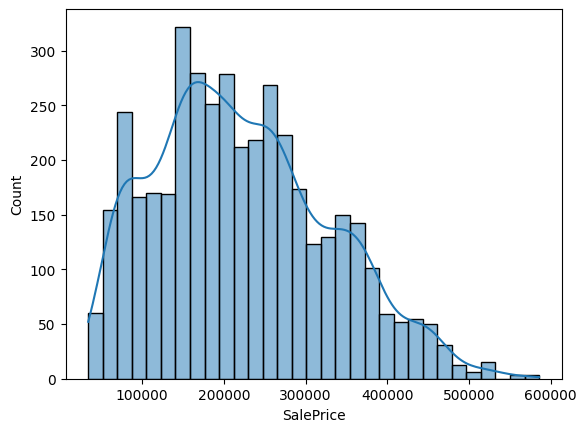

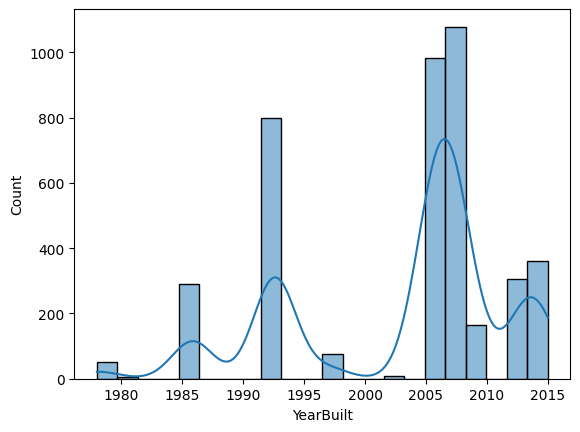

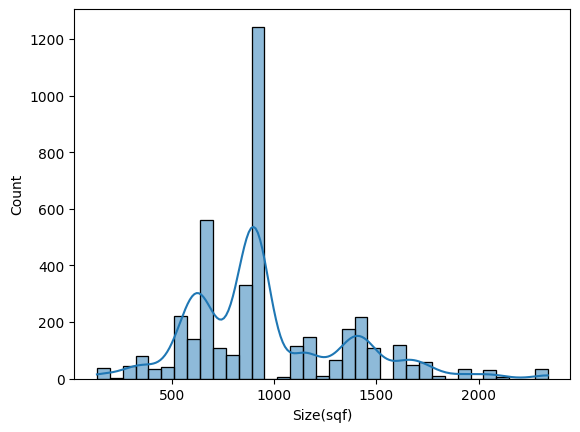

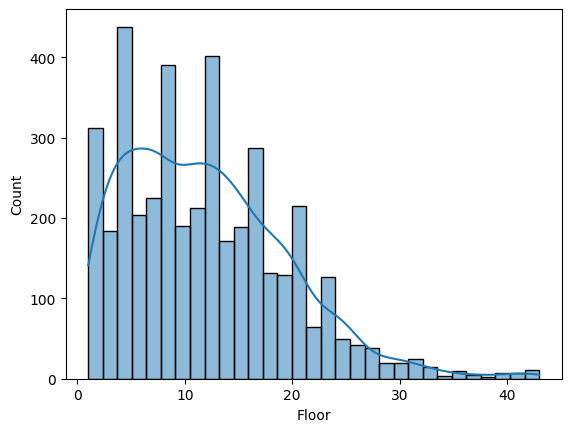

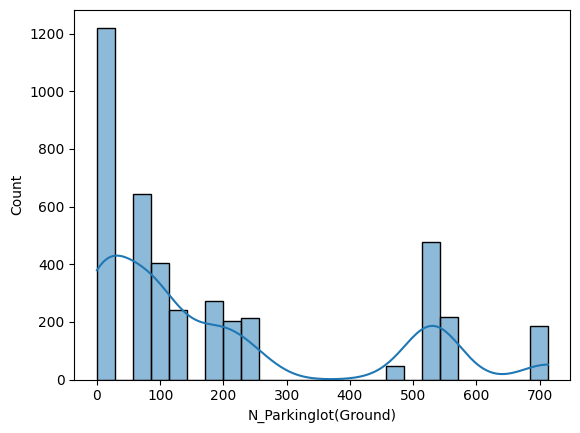

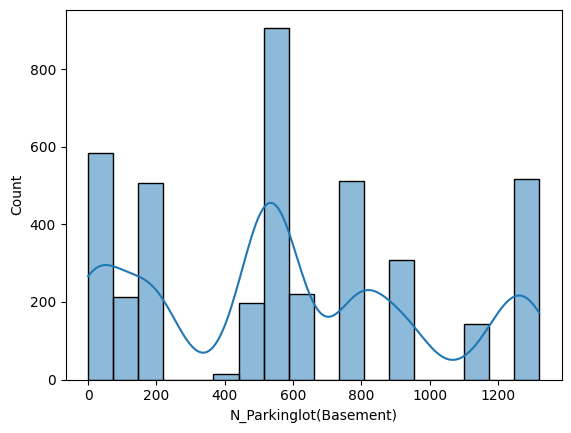

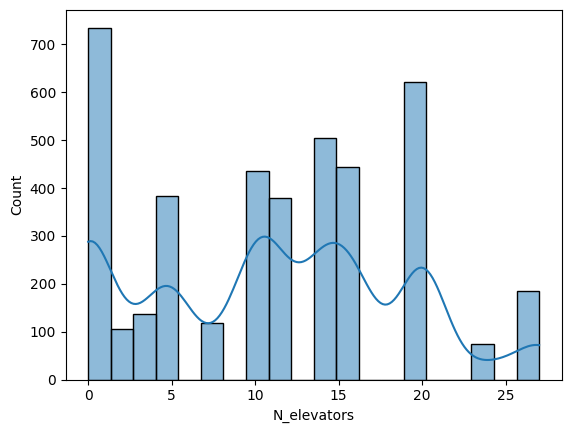

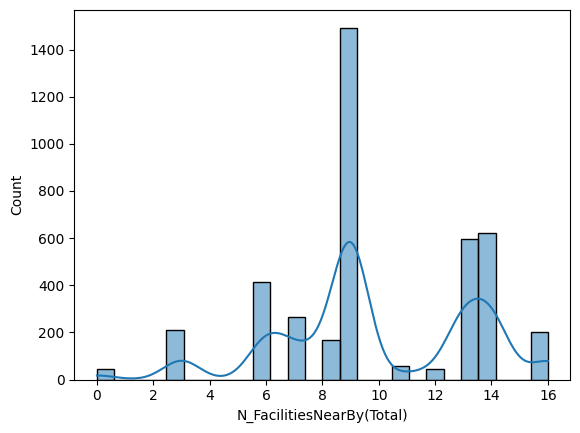

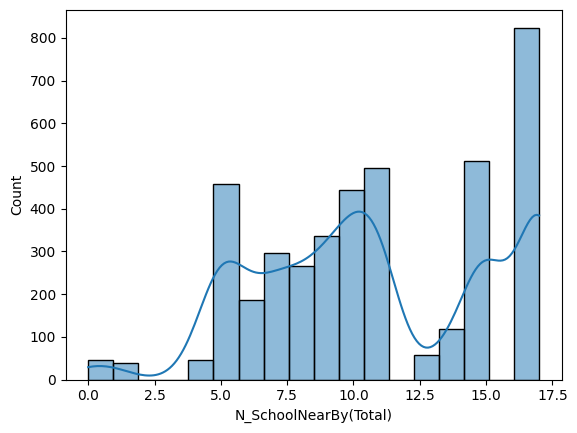

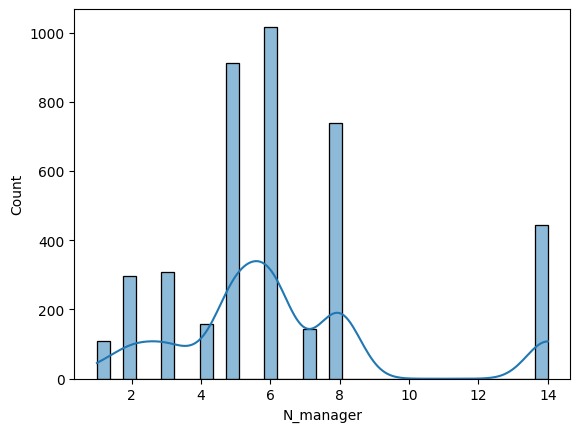

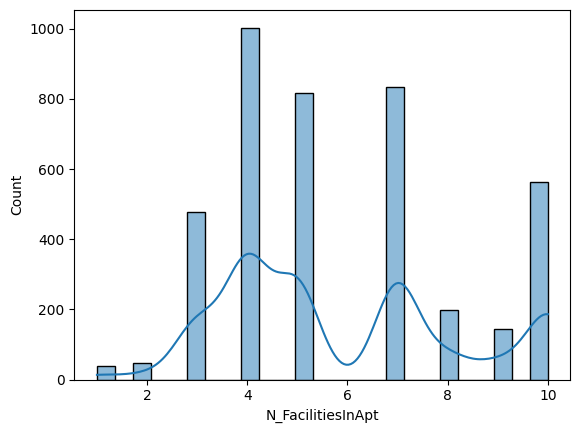

In [35]:
for col in to_scale_cols:
    sns.histplot(df, x=col, kde=True)
    plt.show()

In [35]:
df["Age"] = 2025 - df["YearBuilt"]
df = df.drop(columns=["YearBuilt"])

df["Size(sqf)"] = np.log1p(df["Size(sqf)"])

<Axes: xlabel='Size(sqf)', ylabel='Count'>

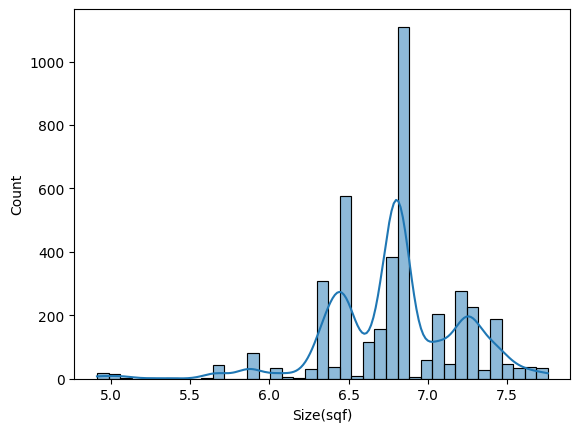

In [13]:
sns.histplot(df, x="Size(sqf)", kde=True)

In [42]:
to_scale_cols

['SalePrice',
 'YearBuilt',
 'Size(sqf)',
 'Floor',
 'N_Parkinglot(Ground)',
 'N_Parkinglot(Basement)',
 'N_elevators',
 'N_FacilitiesNearBy(Total)',
 'N_SchoolNearBy(Total)',
 'N_manager',
 'N_FacilitiesInApt']

In [36]:
from sklearn.preprocessing import RobustScaler

num_cols = [
    "Age",
    "Size(sqf)",
    "N_manager",
    "N_elevators",
    "N_FacilitiesInApt",
    "N_Parkinglot(Basement)",
    "Floor",
    "N_Parkinglot(Ground)",
    "N_FacilitiesNearBy(Total)",
    "N_SchoolNearBy(Total)"
]

scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [15]:
df

,SalePrice,Size(sqf),Floor,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,...,is_terraced,is_Bangoge,is_Banwoldang,is_Chil-sung-market,is_Daegu,is_Kyungbuk_uni_hospital,is_Myung-duk,is_Sin-nam,is_no_subway_nearby,Age
0,141592,-0.189448,-0.727273,1,1,0.046218,-0.573290,0.5,0.75,-1.000000,...,1,0,0,0,0,1,0,0,0,0.000000
1,51327,-0.744855,-0.272727,1,0,-0.084034,-0.749186,0.0,0.25,-1.333333,...,0,0,0,0,1,0,0,0,0,1.500000
2,48672,-0.744855,-0.454545,1,0,-0.084034,-0.749186,0.0,0.25,-1.333333,...,0,0,0,0,1,0,0,0,0,1.500000
3,380530,1.385640,-0.272727,1,1,0.626050,0.000000,0.0,0.00,-0.333333,...,1,0,0,0,0,0,0,1,0,0.000000
4,78318,-0.587445,-0.818182,1,0,0.176471,-0.744300,0.5,0.50,-0.666667,...,0,0,0,0,0,0,1,0,0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796,1.276337,1.181818,1,1,-0.420168,1.195440,0.0,0.00,2.666667,...,1,0,0,0,0,1,0,0,0,-0.071429
4120,307079,-0.587445,1.000000,1,1,0.008403,-0.221498,0.0,0.25,-0.333333,...,1,0,0,0,1,0,0,0,0,-0.642857
4121,357522,-0.080301,0.818182,1,1,-0.420168,1.195440,0.0,0.00,2.666667,...,1,0,0,0,0,1,0,0,0,-0.071429
4122,312389,0.641196,-0.909091,1,0,-0.054622,-0.872964,0.0,0.00,-1.666667,...,0,0,0,0,0,1,0,0,0,2.000000


### Target

In [16]:
conditions = [
    (df["SalePrice"] <= 100000),
    (df["SalePrice"] > 100000) & (df["SalePrice"] <= 350000),
    (df["SalePrice"] > 350000)
]
choices = [0, 1, 2]
df["cls"] = np.select(conditions, choices)
df = df.drop(columns=["SalePrice"])

In [17]:
df["cls"].value_counts()

cls
1    2992
2     570
0     562
Name: count, dtype: int64

In [19]:
df.head()

,Size(sqf),Floor,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,...,is_Bangoge,is_Banwoldang,is_Chil-sung-market,is_Daegu,is_Kyungbuk_uni_hospital,is_Myung-duk,is_Sin-nam,is_no_subway_nearby,Age,cls
0,-0.189448,-0.727273,1,1,0.046218,-0.573290,0.5,0.75,-1.000000,-1.000000,...,0,0,0,0,1,0,0,0,0.0,1
1,-0.744855,-0.272727,1,0,-0.084034,-0.749186,0.0,0.25,-1.333333,-0.818182,...,0,0,0,1,0,0,0,0,1.5,0
2,-0.744855,-0.454545,1,0,-0.084034,-0.749186,0.0,0.25,-1.333333,-0.818182,...,0,0,0,1,0,0,0,0,1.5,0
3,1.385640,-0.272727,1,1,0.626050,0.000000,0.0,0.00,-0.333333,0.000000,...,0,0,0,0,0,0,1,0,0.0,2
4,-0.587445,-0.818182,1,0,0.176471,-0.744300,0.5,0.50,-0.666667,-0.272727,...,0,0,0,0,0,1,0,0,1.0,0
